<a href="https://colab.research.google.com/github/premNatarajanDataScience/sparse-recovery-from-scratch/blob/main/sparse_recovery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# We will designate n as the number of unknowns.
# m is the number of measurements.
# k describes the number of non-zero unknowns.

n = 50
m = 20
k = 5

x_true = np.zeros(n)
position_list = np.random.choice(n, k, replace=False)
random_values = np.random.randn(k)
x_true[position_list] = random_values

In [10]:
# Computing y as the dot product of matrix A and array x_true.
A=np.random.randn(m,n)
y = A @ x_true

# Ensuring that the shape of our resulting matrix is accurate and that there are no errors in computation.

print("A dimensions:", A.shape)
print("x_true dimensions:", x_true.shape)
print("y dimensions:", y.shape)

A dimensions: (20, 50)
x_true dimensions: (50,)
y dimensions: (20,)


In [11]:
# Normalizing A before conducting sparse recovery test. We set the initial residual to y, and initialize x_hat to an array of 0s.

norm_A = A / np.linalg.norm(A, axis=0)
x_hat = np.zeros(n)
residual = y

# We iteratively search for the column with the highest correlation with the residual at each step.
# An entry with the highest correlation value of the columns is placed in an index of x_hat corresponding to that column's position.
# We then recompute the residual.

for w in range(k):
  best_score = -np.inf
  best_position = 0

  for i in range(n):
    score = norm_A[:, i] @ residual
    if best_score < abs(score):
      best_score = abs(score)
      best_position = i

  # Using least-squares regression to minimize error.
  c = (residual @ A[:, best_position]) / (A[:, best_position] @ A[:, best_position])
  x_hat[best_position] = c
  residual = y - (A @ x_hat)

In [12]:
def run_trial(n, m, k):
    # Step 1: build x_true
    x_true = np.zeros(n)
    position_list = np.random.choice(n, k, replace=False)
    random_values = np.random.randn(k)
    x_true[position_list] = random_values


    # Step 2: build A and y
    A=np.random.randn(m,n)
    y = A @ x_true

    # Step 3: run matching pursuit
    norm_A = A / np.linalg.norm(A, axis=0)
    x_hat = np.zeros(n)
    residual = y

    for w in range(k):
      best_score = -np.inf
      best_position = 0

      for i in range(n):
        score = norm_A[:, i] @ residual
        if best_score < abs(score):
          best_score = abs(score)
          best_position = i

      c = (residual @ A[:, best_position]) / (A[:, best_position] @ A[:, best_position])
      x_hat[best_position] = c
      residual = y - (A @ x_hat)


    # Step 4: count how many positions match
    positions_correct = len(np.intersect1d(np.nonzero(x_true)[0], np.nonzero(x_hat)[0]))

    # Step 5: compute final residual and error
    correct_list, residual_list, error_list = [], [], []
    final_residual = np.linalg.norm(residual)
    final_error = np.linalg.norm(x_hat - x_true)
    return positions_correct, final_residual, final_error

In [13]:
num_trials = 100
correct_list, residual_list, error_list = [], [], []
for trial in range(num_trials):
  correct, residual, error = run_trial(n,m,k)
  correct_list.append(correct)
  residual_list.append(residual)
  error_list.append(error)

print("Percentage of positions correct: ", (((sum(correct_list)/num_trials)/k)*100), "%")

Percentage of positions correct:  75.2 %


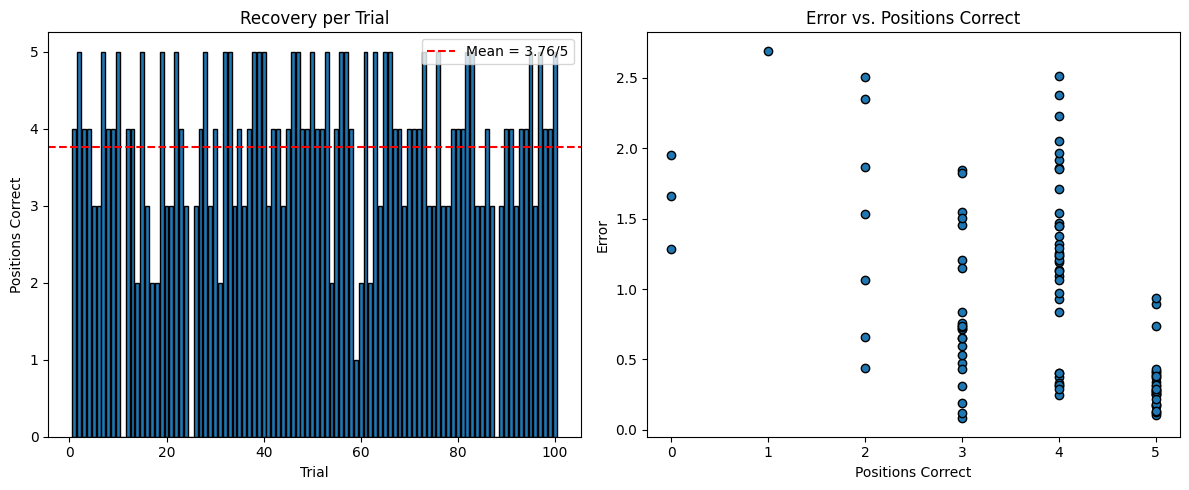

In [14]:
plot_trials = list(range(1, num_trials + 1))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Positions Correct for 100 Trials
axes[0].bar(plot_trials, correct_list, edgecolor="black")
axes[0].axhline(sum(correct_list)/num_trials, color="red", linestyle="--",
                label=f"Mean = {sum(correct_list)/num_trials:.2f}/{k}")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("Positions Correct")
axes[0].set_title("Recovery per Trial")
axes[0].legend()

# Plot 2: Error Given Positions Correct
axes[1].scatter(correct_list, error_list, edgecolor="black")
axes[1].set_xlabel("Positions Correct")
axes[1].set_ylabel("Error")
axes[1].set_title("Error vs. Positions Correct")

plt.tight_layout()
plt.show()